In [1]:
#数据预处理
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

batch_size = 256
try_length = [200,500,1000,1500] # 模型查看的历史窗口大小
prediction_horizon = 1 # 预测的未来窗口大小

directory = "../datas/train" #数据目录
all_items = os.listdir(directory)  #列出目录下所有文件
csv_files = [os.path.join(directory, item) for item in all_items if item.endswith('.csv') and os.path.isfile(os.path.join(directory, item))]  #筛选出CSV文件 
Sample_size = len(csv_files)  #获取样本数量

sequences_data = [] #创建一个空列表，用于存储所有序列的数据
scalers = {} #创建一个空字典，用于存储每个序列对应的标准化器
base_features = ['Voltage', 'Current']
features = ['impedance','cumulative_power']

for file in csv_files:
    df = pd.read_csv(file)
    df['impedance'] = df['Voltage'] * 1000 / df['Current'].replace(0, np.nan)
    df['power'] = df['Voltage'] * (df['Current'] / 1000)
    df['cumulative_power'] = (df['power']/1000).cumsum()
    df = df.ffill().bfill()  #缺失值处理先用前向填充，再用后向填充
    #数据预处理 数值归一化
    scaler = StandardScaler() #为当前序列创建一个新的StandardScaler实例
    df.loc[:, features] = scaler.fit_transform(df.loc[:, features]) #对当前序列的指定特征列进行拟合和转换
    scalers[file] = scaler #将当前序列的标准化器保存到字典中，键为序列ID
    sequences_data.append(df[features + ['Action']].values) #将当前序列的数组数据添加到结果列表中

train_sequences, val_sequences = train_test_split(sequences_data, test_size=0.18, random_state=42)

class MultiSequenceDataset(Dataset):
    def __init__(self, sequences_data, sequence_length, prediction_horizon=1): 
        self.sequences_data = sequences_data # 输入数据
        self.sequence_length = sequence_length # 模型查看的历史窗口大小
        self.prediction_horizon = prediction_horizon # 预测的未来窗口大小
        self.samples = [] #创建一个空列表
        for seq_data in sequences_data: #遍历列表里每一条训练数据数组（多维序列）
            n_samples = len(seq_data) - sequence_length - prediction_horizon + 1 #计算可以生成多少个有效样本：
            for i in range(n_samples): #将n_samples个一个元组 (seq_data, i) 添加到 self.samples 列表中。
                self.samples.append((seq_data, i)) # 生成待截取序列和开始截取的位置列表。
        
    def __len__(self): 
        return len(self.samples)    #返回数据集中样本的总数，即 self.samples 列表的长度。

    def __getitem__(self, idx): 
        seq_data, start_idx = self.samples[idx] #从 self.samples 列表中取出第 idx 个样本对应的原始序列 seq_data 和起始索引 start_idx。
        x = seq_data[start_idx:start_idx + self.sequence_length, :-1]#从 start_idx 开始，截取长度为 sequence_length 的连续时间步。[:, :-1] 表示取所有这些行（时间步），但只取最后一列之前的所有列。
        y_start = start_idx + self.sequence_length #输入序列 x 结束后的下一个时间点。
        y_end = y_start + self.prediction_horizon #y_start 之后的 prediction_horizon 个时间点
        y_window = seq_data[y_start:y_end, -1] # 截取了从 y_start 到 y_end 这个未来窗口内的最后一列，也就是标签列。y_window 是一个一维数组。
        y = 1 if np.any(y_window == 1) else 0
        return torch.FloatTensor(x), torch.FloatTensor([y])

print(f'检索到{Sample_size}个样本')
print(f"特征数量: {len(features)}")
print(f"序列数量: {len(sequences_data)}")
print(f"训练序列: {len(train_sequences)}")
print(f"验证序列: {len(val_sequences)}") 

检索到55个样本
特征数量: 2
序列数量: 55
训练序列: 45
验证序列: 10


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

model_name = 'MLP'

# MLP模型定义
class MLPModel(nn.Module):
    def __init__(self, input_size, hidden_sizes=[256, 128, 64], num_classes=1, dropout_rate=0.3):
        super(MLPModel, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # 动态构建隐藏层
        for i, hidden_size in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # 输出层
        layers.append(nn.Linear(prev_size, num_classes))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        # 将输入展平: [batch_size, seq_len, features] -> [batch_size, seq_len * features]
        batch_size = x.size(0)
        x = x.view(batch_size, -1)
        return self.network(x)
        
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy(inputs, targets, reduction='none')  #前向传播计算
        pt = torch.exp(-BCE_loss) 
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss  #应用 Focal Loss 调制

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

# 训练函数
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    for batch_idx, (data, targets) in enumerate(tqdm(dataloader, desc="已完成", ncols=60)):
        data, targets = data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(data)
        loss = criterion(outputs.squeeze(), targets.squeeze())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        
        # 计算预测结果
        predictions = outputs.squeeze()
        predicted_labels = (predictions > 0.5).float()
        
        all_predictions.extend(predicted_labels.cpu().detach().numpy())
        all_labels.extend(targets.squeeze().cpu().numpy())
        
    epoch_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    
    return epoch_loss, accuracy, precision, recall, f1

# 验证函数
def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            
            outputs = model(data)
            loss = criterion(outputs.squeeze(), targets.squeeze())
            
            running_loss += loss.item()
            
            probabilities = outputs.squeeze()
            predicted_labels = (probabilities > 0.5).float()
            
            all_predictions.extend(predicted_labels.cpu().numpy())
            all_labels.extend(targets.squeeze().cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    
    return epoch_loss, accuracy, precision, recall, f1, all_probabilities

MLP模型配置完成
使用设备: cuda
序列窗口长度: 200
隐藏层配置: [512, 256, 128, 64]
模型参数数量: 379,777
输入尺寸: 400 (序列长度 200 × 特征数 2)
开始训练MLP模型...
使用设备: cuda
最大训练轮数: 100
早停耐心值: 20
初始学习率: 0.001
训练样本数: 544072
验证样本数: 116211


已完成: 100%|██████████| 2126/2126 [00:10<00:00, 207.78it/s]


*** New best model saved! Validation F1: 0.894857 ***
Epoch [  1/100] | EarlyStop [ 0/20] Time: 12.6s | LR: 0.001000
Train Loss: 0.0069 | Train Acc: 0.96% | Val Loss: 0.0042 | Val Acc: 0.97% | Val F1: 0.894857


已完成: 100%|██████████| 2126/2126 [00:09<00:00, 213.34it/s]


*** New best model saved! Validation F1: 0.947825 ***
Epoch [  2/100] | EarlyStop [ 0/20] Time: 12.3s | LR: 0.001000
Train Loss: 0.0059 | Train Acc: 0.96% | Val Loss: 0.0029 | Val Acc: 0.99% | Val F1: 0.947825


...

Epoch [ 22/100] | EarlyStop [18/20] Time: 12.2s | LR: 0.000250
Train Loss: 0.0033 | Train Acc: 0.98% | Val Loss: 0.0082 | Val Acc: 0.94% | Val F1: 0.738064


已完成: 100%|██████████| 2126/2126 [00:10<00:00, 212.09it/s]


*** Learning rate reduced to 0.000125 *** 
Epoch [ 23/100] | EarlyStop [19/20] Time: 12.4s | LR: 0.000125
Train Loss: 0.0033 | Train Acc: 0.98% | Val Loss: 0.0098 | Val Acc: 0.94% | Val F1: 0.745272


已完成: 100%|██████████| 2126/2126 [00:10<00:00, 211.63it/s]


Epoch [ 24/100] | EarlyStop [20/20] Time: 12.4s | LR: 0.000125
Train Loss: 0.0030 | Train Acc: 0.98% | Val Loss: 0.0075 | Val Acc: 0.94% | Val F1: 0.709408


训练完成！早停于第 24 轮, 最佳验证集 F1: 0.9581 于第4轮训练 完成时间20251213_151831
模型已保存为 'Model_MLP_L200.pkl'

最终模型在验证集上的表现:
验证集损失: 0.0075
验证集准确率: 0.9370
验证集精确率: 1.0000
验证集召回率: 0.5497
验证集 F1分数: 0.7094


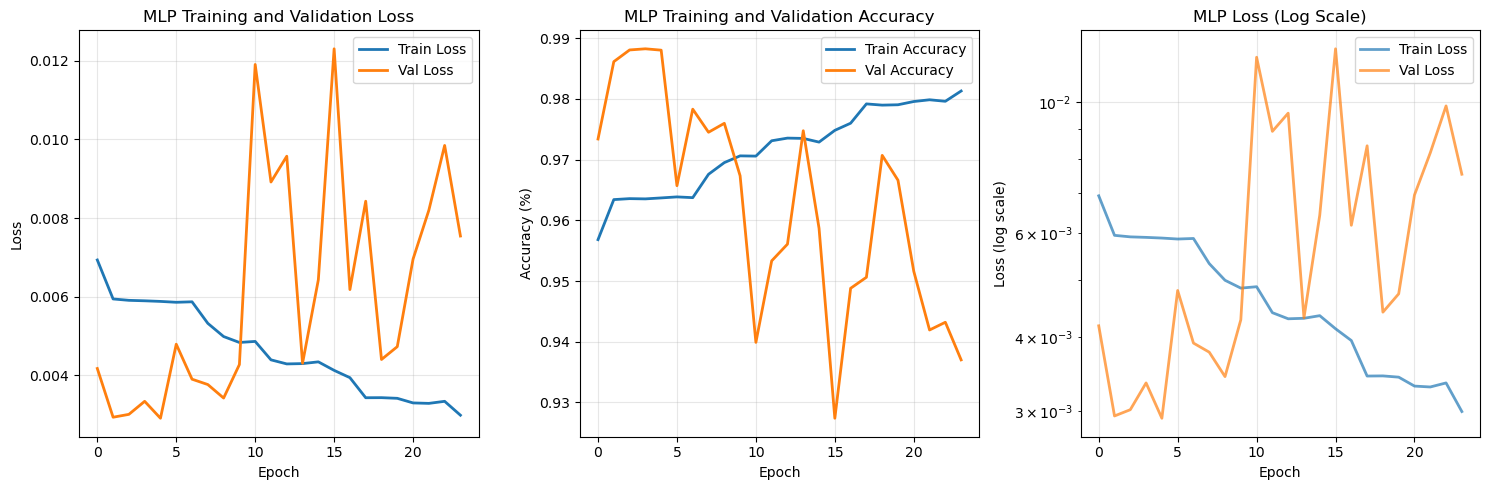

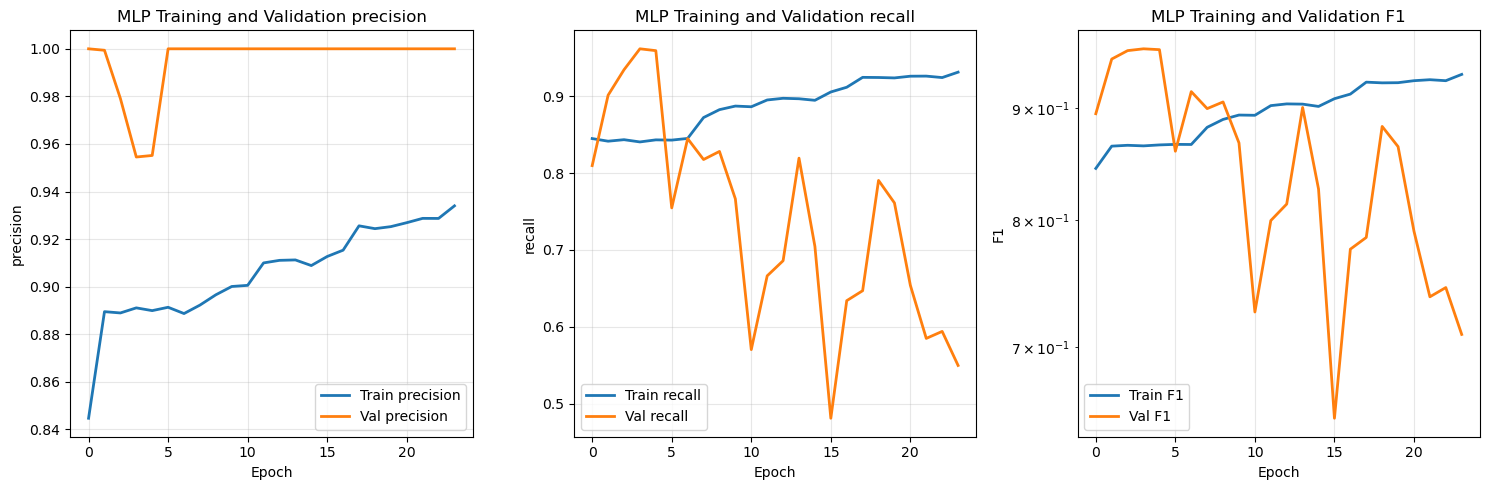

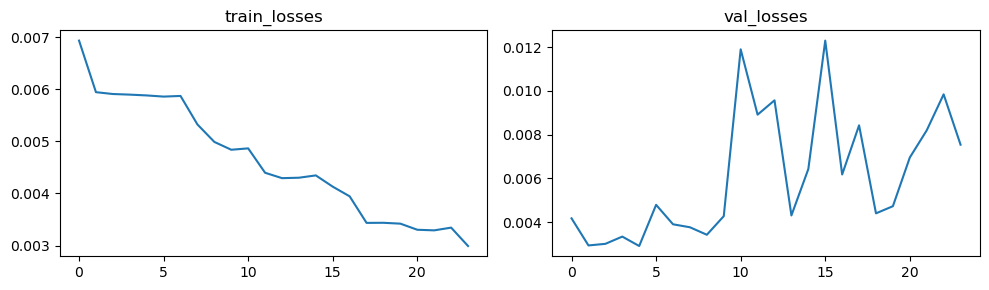

MLP模型配置完成
使用设备: cuda
序列窗口长度: 500
隐藏层配置: [512, 256, 128, 64]
模型参数数量: 686,977
输入尺寸: 1000 (序列长度 500 × 特征数 2)
开始训练MLP模型...
使用设备: cuda
最大训练轮数: 100
早停耐心值: 20
初始学习率: 0.001
训练样本数: 530572
验证样本数: 113211


已完成: 100%|██████████| 2073/2073 [00:10<00:00, 204.70it/s]


*** New best model saved! Validation F1: 0.938873 ***
Epoch [  1/100] | EarlyStop [ 0/20] Time: 12.5s | LR: 0.001000
Train Loss: 0.0073 | Train Acc: 0.95% | Val Loss: 0.0039 | Val Acc: 0.98% | Val F1: 0.938873


已完成: 100%|██████████| 2073/2073 [00:10<00:00, 203.56it/s]


*** New best model saved! Validation F1: 0.951735 ***
Epoch [  2/100] | EarlyStop [ 0/20] Time: 12.6s | LR: 0.001000
Train Loss: 0.0062 | Train Acc: 0.96% | Val Loss: 0.0035 | Val Acc: 0.99% | Val F1: 0.951735


...

*** Learning rate reduced to 0.000125 *** 
Epoch [ 20/100] | EarlyStop [18/20] Time: 12.5s | LR: 0.000125
Train Loss: 0.0030 | Train Acc: 0.98% | Val Loss: 0.0038 | Val Acc: 0.98% | Val F1: 0.908401


已完成: 100%|██████████| 2073/2073 [00:10<00:00, 203.96it/s]


Epoch [ 21/100] | EarlyStop [19/20] Time: 12.5s | LR: 0.000125
Train Loss: 0.0028 | Train Acc: 0.98% | Val Loss: 0.0082 | Val Acc: 0.94% | Val F1: 0.730277


已完成: 100%|██████████| 2073/2073 [00:10<00:00, 204.16it/s]


Epoch [ 22/100] | EarlyStop [20/20] Time: 12.5s | LR: 0.000125
Train Loss: 0.0028 | Train Acc: 0.98% | Val Loss: 0.0098 | Val Acc: 0.93% | Val F1: 0.675764


训练完成！早停于第 22 轮, 最佳验证集 F1: 0.9517 于第2轮训练 完成时间20251213_152309
模型已保存为 'Model_MLP_L500.pkl'

最终模型在验证集上的表现:
验证集损失: 0.0098
验证集准确率: 0.9297
验证集精确率: 1.0000
验证集召回率: 0.5103
验证集 F1分数: 0.6758


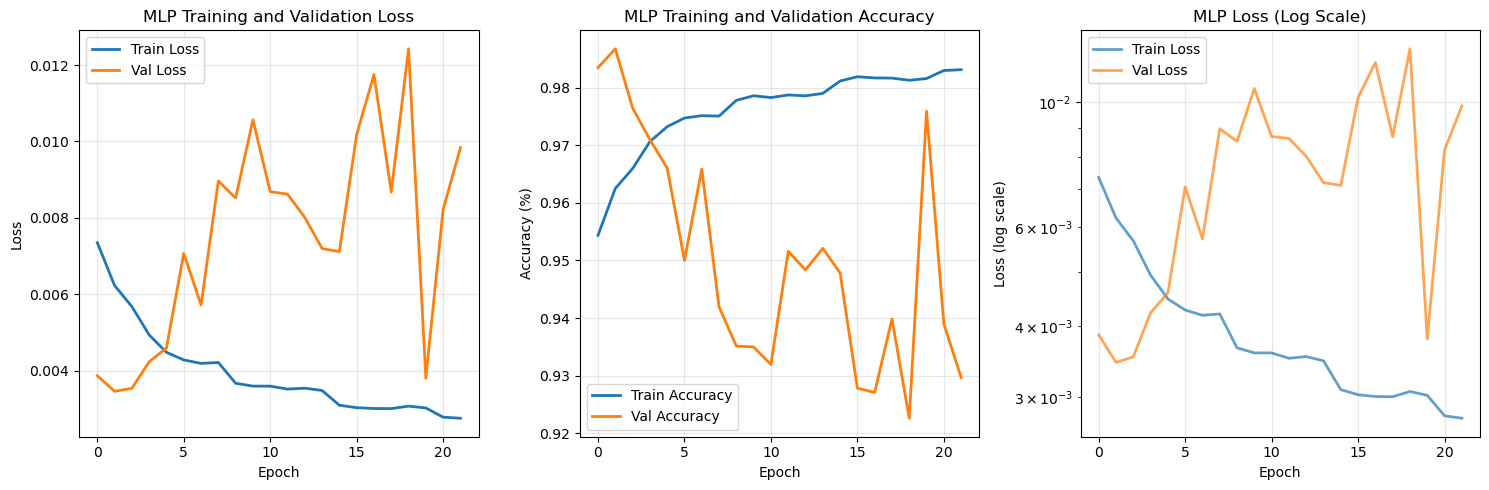

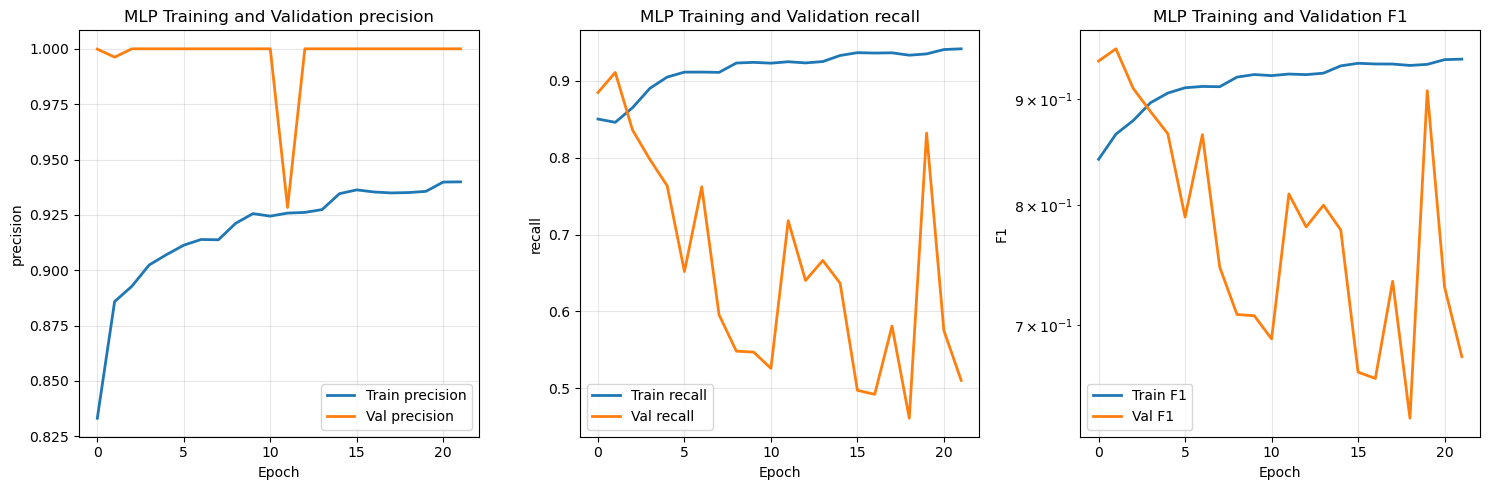

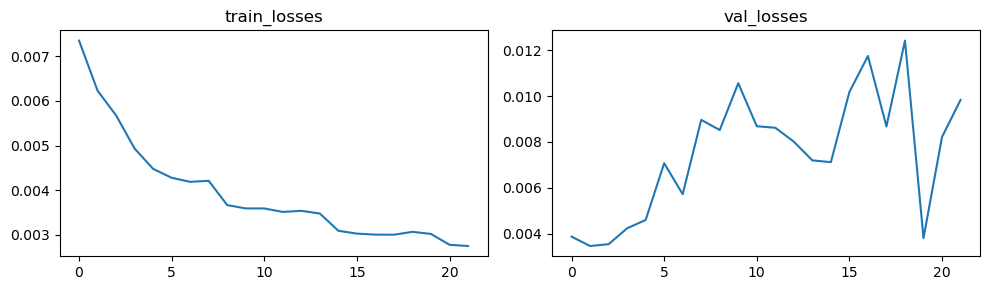

MLP模型配置完成
使用设备: cuda
序列窗口长度: 1000
隐藏层配置: [512, 256, 128, 64]
模型参数数量: 1,198,977
输入尺寸: 2000 (序列长度 1000 × 特征数 2)
开始训练MLP模型...
使用设备: cuda
最大训练轮数: 100
早停耐心值: 20
初始学习率: 0.001
训练样本数: 508072
验证样本数: 108211


已完成: 100%|██████████| 1985/1985 [00:10<00:00, 188.68it/s]


*** New best model saved! Validation F1: 0.927143 ***
Epoch [  1/100] | EarlyStop [ 0/20] Time: 12.9s | LR: 0.001000
Train Loss: 0.0070 | Train Acc: 0.96% | Val Loss: 0.0037 | Val Acc: 0.98% | Val F1: 0.927143


已完成: 100%|██████████| 1985/1985 [00:10<00:00, 188.00it/s]


*** New best model saved! Validation F1: 0.931737 ***
Epoch [  2/100] | EarlyStop [ 0/20] Time: 12.9s | LR: 0.001000
Train Loss: 0.0048 | Train Acc: 0.97% | Val Loss: 0.0033 | Val Acc: 0.98% | Val F1: 0.931737


...

*** Learning rate reduced to 0.000063 *** 
Epoch [ 28/100] | EarlyStop [18/20] Time: 13.0s | LR: 0.000063
Train Loss: 0.0028 | Train Acc: 0.98% | Val Loss: 0.0069 | Val Acc: 0.95% | Val F1: 0.794408


已完成: 100%|██████████| 1985/1985 [00:10<00:00, 188.25it/s]


Epoch [ 29/100] | EarlyStop [19/20] Time: 12.9s | LR: 0.000063
Train Loss: 0.0026 | Train Acc: 0.98% | Val Loss: 0.0079 | Val Acc: 0.95% | Val F1: 0.791854


已完成: 100%|██████████| 1985/1985 [00:10<00:00, 193.04it/s]


Epoch [ 30/100] | EarlyStop [20/20] Time: 12.7s | LR: 0.000063
Train Loss: 0.0026 | Train Acc: 0.98% | Val Loss: 0.0074 | Val Acc: 0.95% | Val F1: 0.803372


训练完成！早停于第 30 轮, 最佳验证集 F1: 0.9555 于第10轮训练 完成时间20251213_152939
模型已保存为 'Model_MLP_L1000.pkl'

最终模型在验证集上的表现:
验证集损失: 0.0074
验证集准确率: 0.9506
验证集精确率: 1.0000
验证集召回率: 0.6714
验证集 F1分数: 0.8034


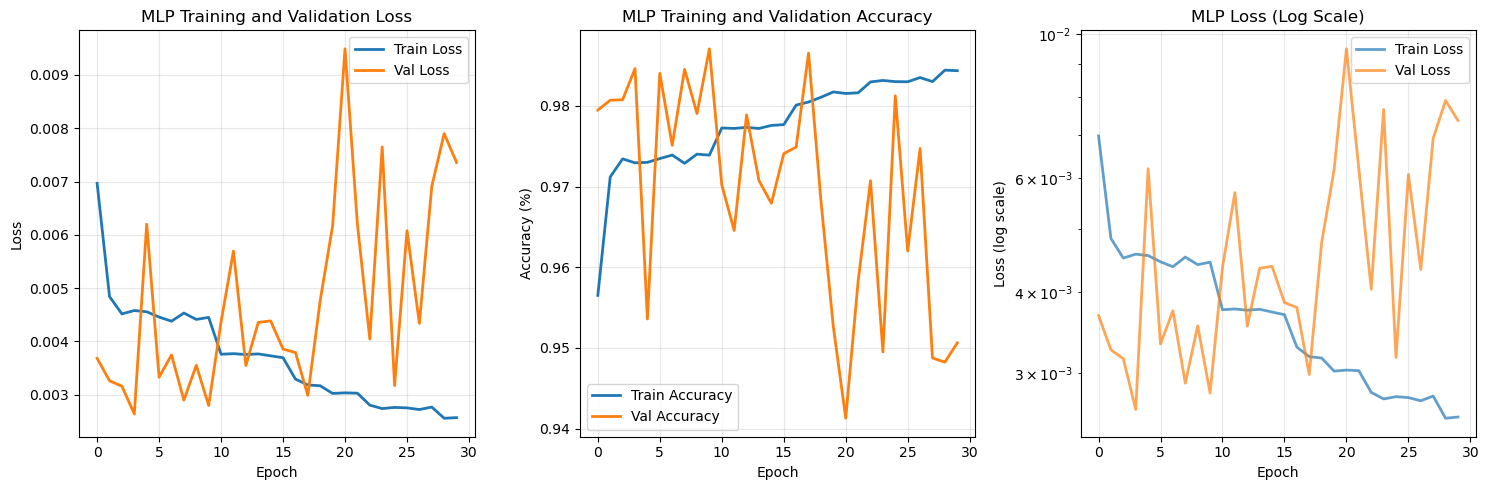

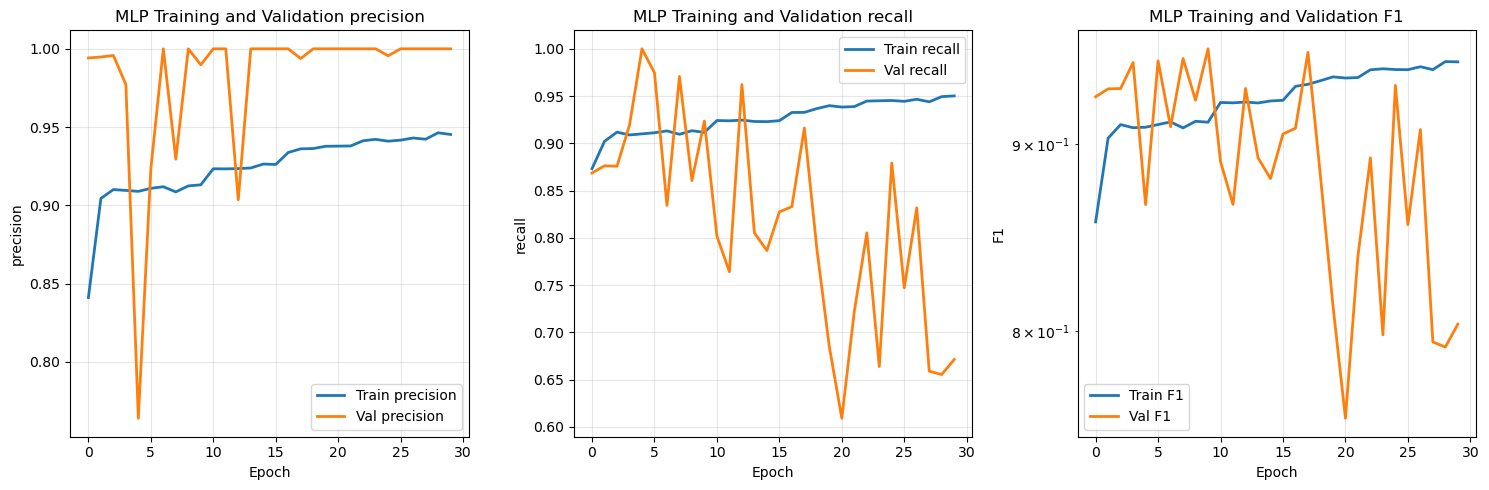

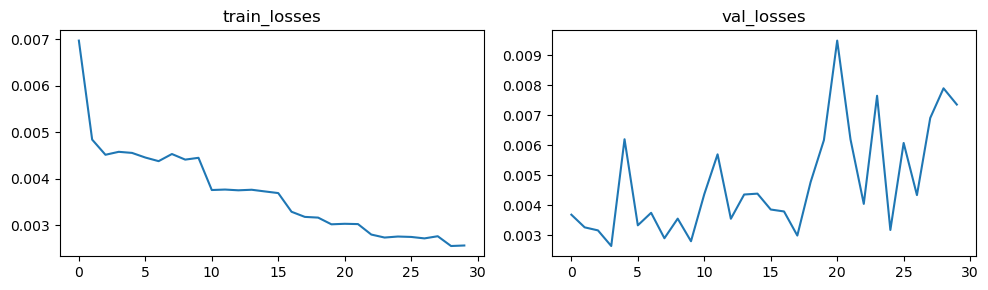

MLP模型配置完成
使用设备: cuda
序列窗口长度: 1500
隐藏层配置: [512, 256, 128, 64]
模型参数数量: 1,710,977
输入尺寸: 3000 (序列长度 1500 × 特征数 2)
开始训练MLP模型...
使用设备: cuda
最大训练轮数: 100
早停耐心值: 20
初始学习率: 0.001
训练样本数: 485572
验证样本数: 103211


已完成: 100%|██████████| 1897/1897 [00:10<00:00, 178.10it/s]


*** New best model saved! Validation F1: 0.950735 ***
Epoch [  1/100] | EarlyStop [ 0/20] Time: 13.0s | LR: 0.001000
Train Loss: 0.0067 | Train Acc: 0.96% | Val Loss: 0.0025 | Val Acc: 0.98% | Val F1: 0.950735


已完成: 100%|██████████| 1897/1897 [00:10<00:00, 178.33it/s]


Epoch [  2/100] | EarlyStop [ 1/20] Time: 13.0s | LR: 0.001000
Train Loss: 0.0048 | Train Acc: 0.97% | Val Loss: 0.0076 | Val Acc: 0.94% | Val F1: 0.831075


...

Epoch [ 21/100] | EarlyStop [18/20] Time: 13.0s | LR: 0.000125
Train Loss: 0.0027 | Train Acc: 0.98% | Val Loss: 0.0048 | Val Acc: 0.98% | Val F1: 0.925763


已完成: 100%|██████████| 1897/1897 [00:10<00:00, 178.48it/s]


Epoch [ 22/100] | EarlyStop [19/20] Time: 13.0s | LR: 0.000125
Train Loss: 0.0027 | Train Acc: 0.98% | Val Loss: 0.0101 | Val Acc: 0.95% | Val F1: 0.801254


已完成: 100%|██████████| 1897/1897 [00:10<00:00, 179.47it/s]


Epoch [ 23/100] | EarlyStop [20/20] Time: 12.9s | LR: 0.000125
Train Loss: 0.0027 | Train Acc: 0.98% | Val Loss: 0.0043 | Val Acc: 0.97% | Val F1: 0.912709


训练完成！早停于第 23 轮, 最佳验证集 F1: 0.9617 于第3轮训练 完成时间20251213_153440
模型已保存为 'Model_MLP_L1500.pkl'

最终模型在验证集上的表现:
验证集损失: 0.0043
验证集准确率: 0.9747
验证集精确率: 1.0000
验证集召回率: 0.8394
验证集 F1分数: 0.9127


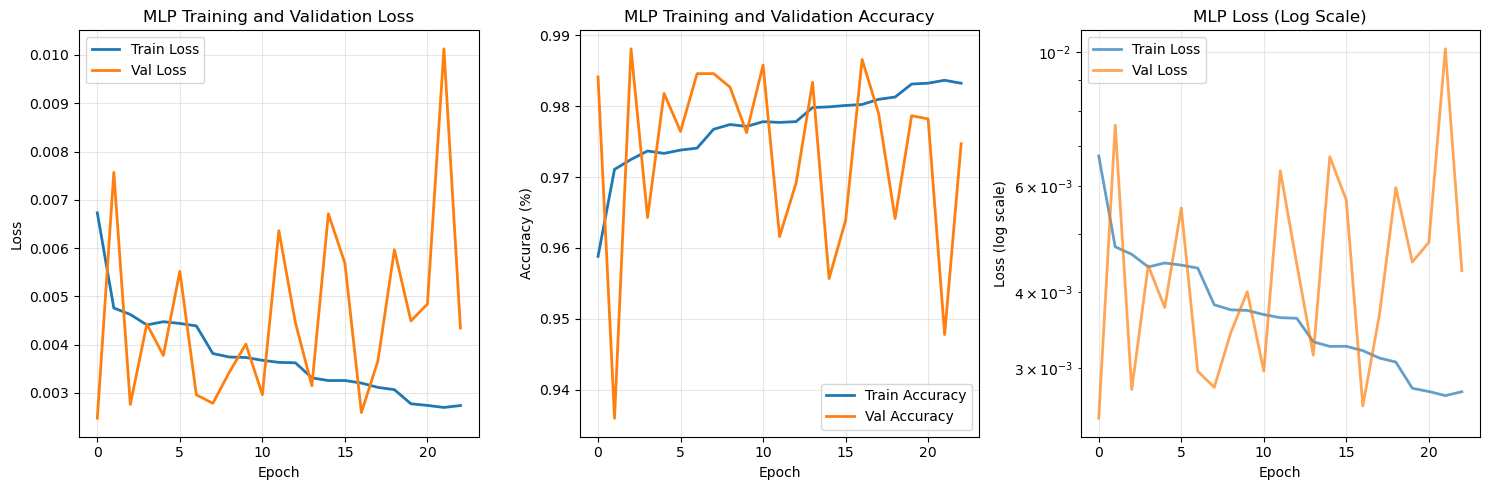

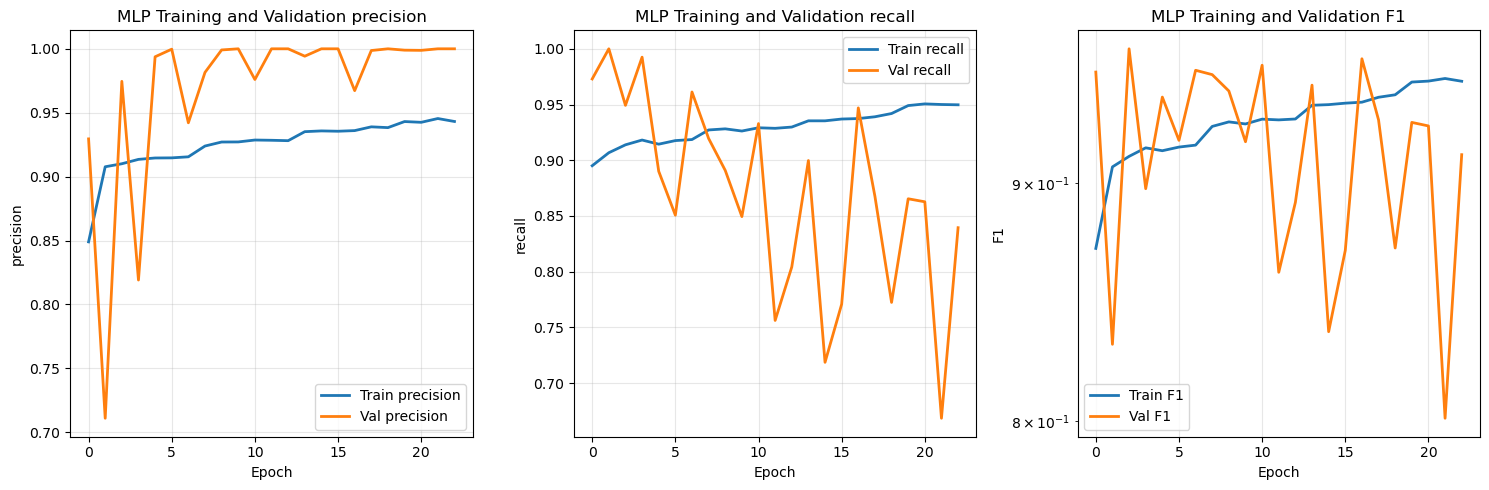

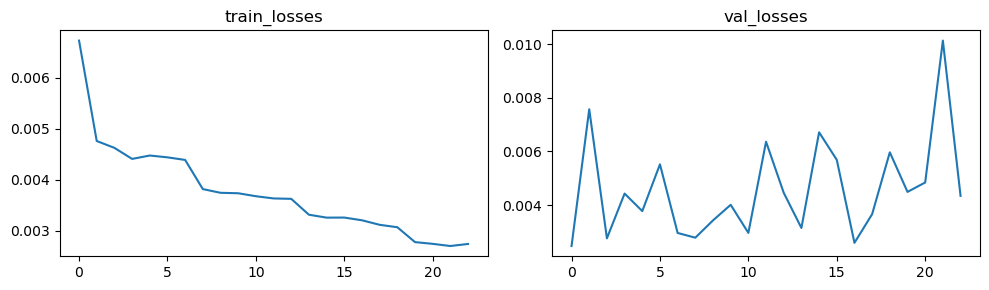

In [3]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import time
from datetime import datetime
import matplotlib.pyplot as plt

for sequence_length in try_length:
    
    learning_rate = 0.001
    num_epochs = 100
    patience = 20
    
    # 训练循环
    train_losses = []
    val_losses = []
    train_metrics = []
    val_metrics = []
    
    best_val_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    current_lr = learning_rate
    
    train_dataset = MultiSequenceDataset(train_sequences, sequence_length, prediction_horizon)
    val_dataset = MultiSequenceDataset(val_sequences, sequence_length, prediction_horizon)
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

    # 计算输入尺寸
    # sequence_length * 特征数量 (base_features + new_features 的数量)
    input_features = len(features)  # 特征数量
    input_size = sequence_length * input_features
    hidden_sizes=[512, 256, 128, 64]
    
    # 初始化模型
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLPModel(input_size, 
                     hidden_sizes, 
                     dropout_rate=0.4).to(device)
    # 定义损失函数和优化器
    criterion = FocalLoss(alpha=0.25, gamma=2.0)  # nn.BCELoss()  # nn.BCEWithLogitsLoss()

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    print("=" * 80)
    print(f"MLP模型配置完成")
    print(f"使用设备: {device}")
    print(f"序列窗口长度: {sequence_length}")
    print(f"隐藏层配置: {hidden_sizes}")
    print(f"模型参数数量: {sum(p.numel() for p in model.parameters()):,}")
    print(f"输入尺寸: {input_size} (序列长度 {sequence_length} × 特征数 {input_features})")
    print(f"开始训练{model_name}模型...")
    print(f"使用设备: {device}")
    print(f"最大训练轮数: {num_epochs}")
    print(f"早停耐心值: {patience}")
    print(f"初始学习率: {learning_rate}")
    print(f"训练样本数: {len(train_dataset)}")
    print(f"验证样本数: {len(val_dataset)}")
    print("=" * 80)
    
    for epoch in range(num_epochs):
    
        epoch_start_time = time.time()
        # 训练
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_epoch(
            model, train_loader, criterion, optimizer, device)
        
        # 验证
        val_loss, val_acc, val_prec, val_rec, val_f1, val_probs = validate_epoch(
            model, val_loader, criterion, device)
    
        epoch_time = time.time() - epoch_start_time
        
        # 学习率调度
        scheduler.step(val_loss)
        if current_lr != optimizer.param_groups[0]['lr']:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'*** Learning rate reduced to {current_lr:.6f} *** ')
            
        # 保存损失和指标
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_metrics.append((train_acc, train_prec, train_rec, train_f1))
        val_metrics.append((val_acc, val_prec, val_rec, val_f1))
        
        # 保存最佳模型
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'Model_{model_name}_FocalLoss_L{sequence_length}.pkl')
            print(f'*** New best model saved! Validation F1: {val_f1:.6f} ***')
        else:
            patience_counter += 1
        
        # 打印训练信息
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] | EarlyStop [{patience_counter:2d}/{patience}] Time: {epoch_time:.1f}s | LR: {current_lr:.6f}')
        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% |', end='')
        print(f' Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val F1: {val_f1:.6f}')
        
        # 早停
        if patience_counter >= patience:
            print(f"\n")
            break
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(f"训练完成！早停于第 {epoch+1} 轮, 最佳验证集 F1: {best_val_f1:.4f} 于第{best_epoch}轮训练", end=" ")
    print(f"完成时间{timestamp}")
    print(f"模型已保存为 'Model_{model_name}_L{sequence_length}.pkl'")
    
    # 最终评估
    print("\n最终模型在验证集上的表现:")
    final_val_loss, final_val_acc, final_val_prec, final_val_rec, final_val_f1, _ = validate_epoch(
        model, val_loader, criterion, device)
    
    print(f"验证集损失: {final_val_loss:.4f}")
    print(f"验证集准确率: {final_val_acc:.4f}")
    print(f"验证集精确率: {final_val_prec:.4f}")
    print(f"验证集召回率: {final_val_rec:.4f}")
    print(f"验证集 F1分数: {final_val_f1:.4f}")

    train_metrics_array = np.array(train_metrics)
    val_metrics_array = np.array(val_metrics)
    
    # 绘制训练曲线
    fig1 = plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', linewidth=2)
    plt.plot(val_losses, label='Val Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Training and Validation Loss')
    
    plt.subplot(1, 3, 2)
    plt.plot(train_metrics_array[:, 0], label='Train Accuracy', linewidth=2)
    plt.plot(val_metrics_array[:, 0], label='Val Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Training and Validation Accuracy')
    
    # 绘制学习率变化
    plt.subplot(1, 3, 3)
    plt.semilogy(train_losses, label='Train Loss', alpha=0.7, linewidth=2)
    plt.semilogy(val_losses, label='Val Loss', alpha=0.7, linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Loss (Log Scale)')
    
    plt.tight_layout()
    save_dir = f'Test_results_{model_name}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f'model_train_L{sequence_length}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    fig2 = plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(train_metrics_array[:, 1], label='Train precision', linewidth=2)
    plt.plot(val_metrics_array[:, 1], label='Val precision', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('precision')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Training and Validation precision')
    
    plt.subplot(1, 3, 2)
    plt.plot(train_metrics_array[:, 2], label='Train recall', linewidth=2)
    plt.plot(val_metrics_array[:, 2], label='Val recall', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('recall')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Training and Validation recall')
    
    # 绘制学习率变化
    plt.subplot(1, 3, 3)
    plt.semilogy(train_metrics_array[:, 3], label='Train F1', linewidth=2)
    plt.semilogy(val_metrics_array[:, 3], label='Val F1', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('F1')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'{model_name} Training and Validation F1')
    
    plt.tight_layout()
    save_dir = f'Test_results_{model_name}'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, f'model_train2_L{sequence_length}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
    # 在第一个子图上绘制
    ax1.plot(train_losses)
    ax1.set_title('train_losses')
    
    # 在第二个子图上绘制
    ax2.plot(val_losses)
    ax2.set_title('val_losses')
    
    plt.tight_layout()  # 自动调整子图间距
    plt.savefig(os.path.join(save_dir, f'model_train3_L{sequence_length}.png'), dpi=300, bbox_inches='tight')
    plt.show()